<a href="https://colab.research.google.com/github/oooinr4018-web/-1/blob/main/0904_%EC%84%B8%EC%85%98_%EB%B6%84%EB%A5%98_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **분류 연습 문제**
___
출처 : 핸즈온 머신러닝 Ch03 분류 연습문제 1, 2번

In [5]:
# import data
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version = 1, as_frame = False)

In [6]:
X, y = mnist["data"], mnist["target"]

In [7]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

### **1. MNIST 데이터셋으로 분류기를 만들어 테스트 세트에서 97% 정확도를 달성해보세요.**
___

1. `KNeghtborsClassifier`를 사용하는 것을 추천합니다.
2. `weights`와 `n_neighbors` 하이퍼 파라미터로 그리드 탐색을 시도하여, 좋은 하이퍼 파라미터 값을 찾아보세요.

In [8]:
# import package
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [9]:
# Try GridSearch to optimize hyperparameter
param_grid={
    "n_neighbors":[3,4,5],
    "weights":["uniform","distance"]
}

knn_clf=KNeighborsClassifier()

grid_search=GridSearchCV(
    knn_clf,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 4, 5],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=2)

In [10]:
# best hyperparameter
grid_search.best_params_

{'n_neighbors': 4, 'weights': 'distance'}

In [11]:
# best score
grid_search.best_score_

np.float64(0.9716166666666666)

In [12]:
# model test
best_knn=grid_search.best_estimator_
y_pred=best_knn.predict(X_test)
accuracy=accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9714


### **2. 다음 단계를 따라 인위적으로 훈련 세트를 늘리는 데이터 증식 또는 훈련 세트 확장 기법을 연습해봅시다.**
___

#### **STEP 1. MNIST 이미지를 (왼, 오른, 위, 아래) 어느 방향으로든 한 픽셀 이동시킬 수 있는 함수를 만들어 보세요.**

In [16]:
# 이미지를 한 픽셀 이동시키는 함수

import numpy as np

def shift_image(image, dx, dy):

  # 784개의 값을 28x28 이미지로 변환
  image=image.reshape(28,28)

  # 이미지 이동
  shifted_image=np.roll(
      image,
      shift=(dy,dx),
      axis=(0,1)
  )

  # 이동하면서 반대편으로 넘어온 부분을 0으로 처리
  if dy>0:
    shifted_image[:dy,:]=0

  elif dy<0:
    shifted_image[:dy,:]=0

  if dx>0:
      shifted_image[:,:dx]=0

  elif dx<0:
    shifted_image[:,dx:]=0

  return shifted_image.reshape(-1)


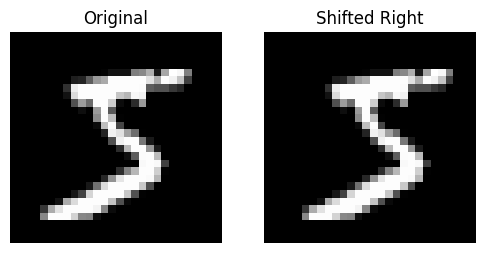

In [17]:
# 제대로 이동하는지 확인

import matplotlib.pyplot as plt

image=X_train[0]

shifted_image=shift_image(image, dx=1, dy=0)

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(image.reshape(28,28), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(shifted_image.reshape(28,28), cmap="gray")
plt.title("Shifted Right")
plt.axis("off")

plt.show()

####  **STEP 2. 앞에서 만든 함수를 이용하여, 훈련 세트에 있는 각 이미지에 대해 네 개의 이동된 복사본(방향마다 한 개씩)을 만들어 훈련 세트에 추가하세요**

In [18]:
X_train_augmented=[image for image in X_train]
y_train_augmented=[label for label in y_train]

# 왼쪽, 오른쪽, 위, 아래
directions=[
    (-1,0),
    (1,0),
    (0,-1),
    (0,1)
]

for dx, dy in directions:

  for image, label in zip(X_train, y_train):

    shifted=shift_image(image, dx, dy)

    X_train_augmented.append(shifted)
    y_train_augmented.append(label)

In [19]:
X_train_augmented=np.array(
    X_train_augmented,
    dtype=np.uint8
)

y_train_augmented=np.array(
    y_train_augmented,
    dtype=np.uint8
)

# 데이터 순서 섞기
shuffle_idx=np.random.default_rng(42).permutation(
    len(X_train_augmented)
)

X_train_augmented=X_train_augmented[shuffle_idx]
y_train_augmented=y_train_augmented[shuffle_idx]

print(X_train.shape)
print(X_train_augmented.shape)

(60000, 784)
(300000, 784)


####  **STEP 3. 위에서 확장한 데이터셋을 이용하여, 1번 문제에서 찾은 최적 모델을 훈련시키고, 테스트 세트에서 정확도를 측정해보세요**

In [20]:
# 증강한 데이터로 최적 KNN 다시 학습
knn_clf_augmented=KNeighborsClassifier(
    **grid_search.best_params_
)

In [21]:
# 학습
knn_clf_augmented.fit(
    X_train_augmented,
    y_train_augmented
)

KNeighborsClassifier(n_neighbors=4, weights='distance')

In [22]:
# 테스트 정확도

y_pred_augmented=knn_clf_augmented.predict(X_test)

accuracy_augmented=accuracy_score(
    y_test,
    y_pred_augmented
)

print("Augmented Test Accuracy:", accuracy_augmented)

Augmented Test Accuracy: 0.0
